# scikit-learn Bootcamp — W1, Day 6
```
##### Random Forests
##### RandomForestClassifier · bagging · n_estimators · OOB · feature importance · bias-variance
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Q1 — EDA: pairplot of top features coloured by class
##### Q2 — Random Forest vs single tree: accuracy and stability
##### Q3 — n_estimators sweep: when do more trees stop helping?
##### Q4 — OOB score: free validation without a test set
##### Q5 — Feature importance: RF vs Decision Tree — do they agree?
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, f1_score
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); np.random.seed(420)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
import time

---
### Dataset — MedPulse Sessions (n=5000)
```
# Larger dataset to demonstrate RF stability benefits.
```

In [4]:
np.random.seed(420)
n = 5000
age=np.random.normal(43,12,n).clip(18,80).astype(int)
session_depth=np.random.poisson(3.8,n).clip(1,20)
time_on_site=np.random.lognormal(1.7,0.75,n).clip(0.5,80)
articles_read=np.random.poisson(2.5,n).clip(0,15)
is_mobile=np.random.binomial(1,0.59,n)
health_content=np.random.beta(2.5,2,n)
log_odds=(-3.8+0.22*session_depth+0.06*time_on_site+0.18*articles_read
          +1.1*health_content-0.25*is_mobile+0.007*age+np.random.normal(0,0.5,n))
converted=np.random.binomial(1,1/(1+np.exp(-log_odds)))
df=pd.DataFrame({'age':age,'session_depth':session_depth,'time_on_site':time_on_site.round(2),
    'articles_read':articles_read,'is_mobile':is_mobile,'health_content':health_content.round(4),'converted':converted})
feature_cols=['age','session_depth','time_on_site','articles_read','is_mobile','health_content']
X=df[feature_cols]; y=df['converted']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=420,stratify=y)
print(f'Shape: {df.shape} | Conversion: {y.mean():.2%}')

Shape: (5000, 7) | Conversion: 23.66%


---
### Q1 — EDA: pairplot of top features
```
# (a) Pairplot of the 4 most correlated features coloured by converted.
# (b) Bar chart: feature correlation with target.
# (c) Class-conditional violin plots for session_depth and health_content.
# (d) Which features show clear separation between classes?
```

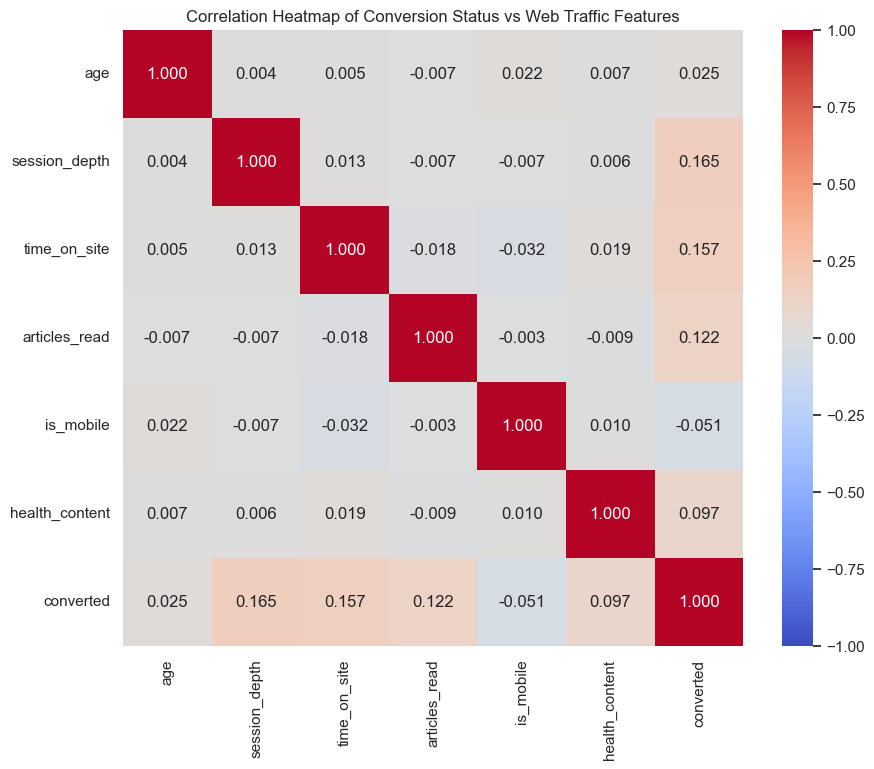


Linear Correlation with converted:
converted         1.000000
session_depth     0.164658
time_on_site      0.156535
articles_read     0.122161
health_content    0.097424
age               0.025103
is_mobile        -0.050555
Name: converted, dtype: float64


In [7]:
# (a) Pairplot of the 4 most correlated features coloured by converted.

# 1. Keep target, but drop the leaking binary indicator column
numeric_df = df.select_dtypes(include=[np.number])

# 2. Compute correlation matrix including the target
corr_matrix = numeric_df.corr()

# 3. Render the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Conversion Status vs Web Traffic Features')
plt.show()

# 4. Print exact correlation vector sorted to find the strongest signal
print("\nLinear Correlation with converted:")
print(corr_matrix['converted'].sort_values(ascending=False))

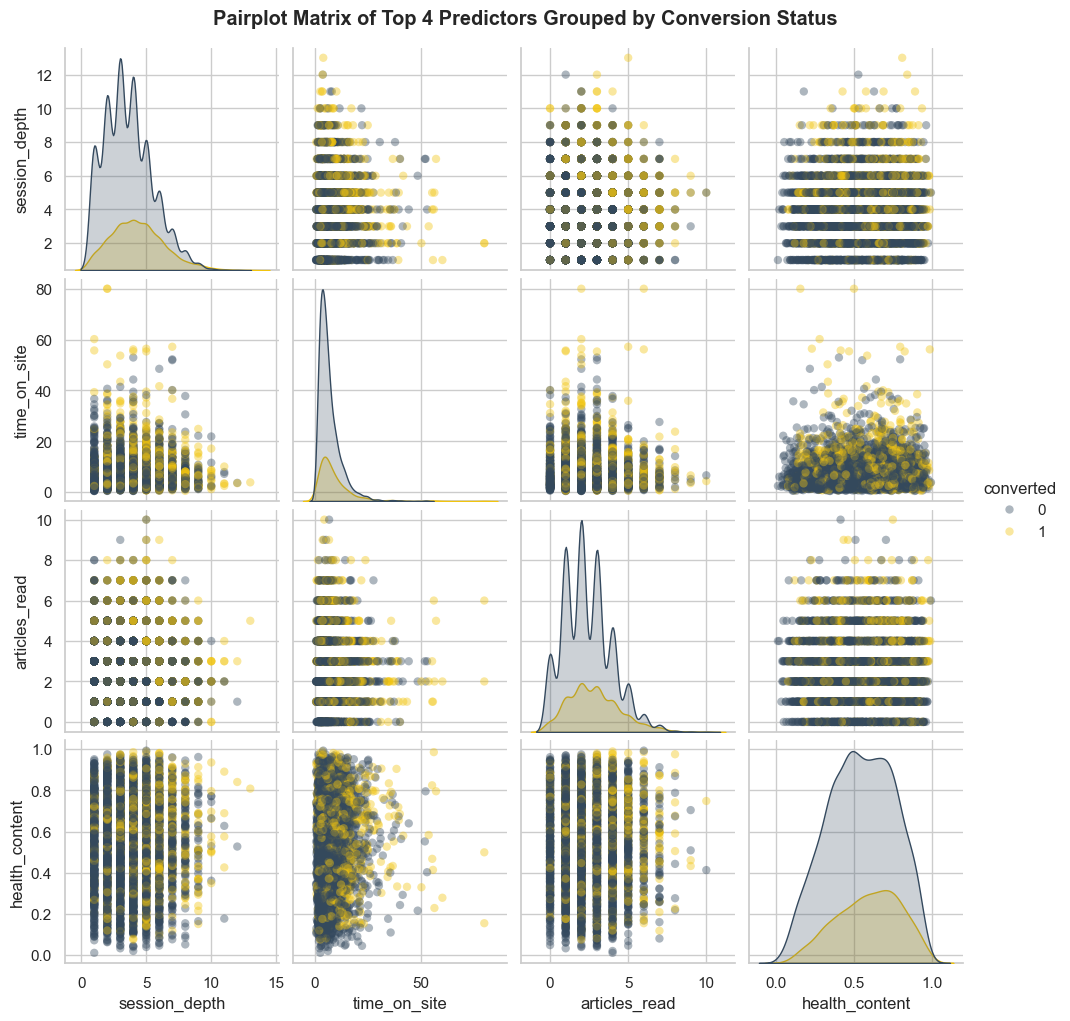

In [12]:
# Specify the features we want to compare
top_4_features = ['session_depth', 'time_on_site', 'articles_read', 'health_content']

sns.pairplot(
    data=df, 
    vars=top_4_features, 
    hue='converted', 
    palette={0: '#34495e', 1: '#f1c40f'},
    plot_kws={'alpha': 0.4, 'edgecolor': 'none'},
    diag_kind='kde'
)

plt.suptitle('Pairplot Matrix of Top 4 Predictors Grouped by Conversion Status', y=1.02, fontweight='bold')
plt.show()

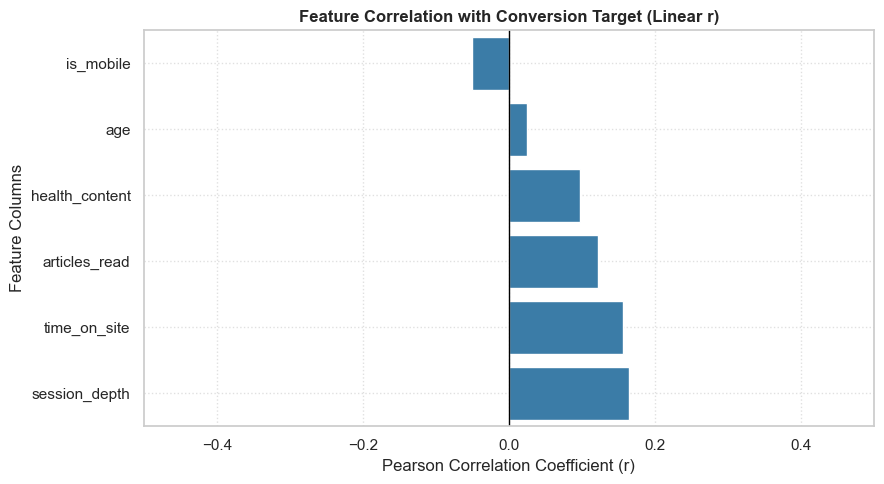

       Feature  Correlation
 session_depth     0.164658
  time_on_site     0.156535
 articles_read     0.122161
health_content     0.097424
           age     0.025103
     is_mobile    -0.050555


In [17]:
# (b) Bar chart: feature correlation with target.

# 1. Compute the correlation matrix on the numeric features
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. Extract correlation with the target column and drop the self-correlation row
target_corr = corr_matrix['converted'].drop('converted').reset_index()
target_corr.columns = ['Feature', 'Correlation']

# 3. Sort the features from lowest to highest correlation for a clean plot flow
target_corr = target_corr.sort_values('Correlation', ascending=True)

# 4. Generate the horizontal bar chart
plt.figure(figsize=(9, 5))
sns.barplot(
    data=target_corr,
    x='Correlation',
    y='Feature',
    color='#2980b9'
)

# 5. Customize the canvas style and axis lines
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)  # Clear zero-correlation baseline
plt.title('Feature Correlation with Conversion Target (Linear r)', fontweight='bold', fontsize=12)
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.ylabel('Feature Columns')
plt.xlim(-0.5, 0.5)  # Constrained window based on your data scales
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Print the numerical vector for verification
print(target_corr.sort_values('Correlation', ascending=False).to_string(index=False))


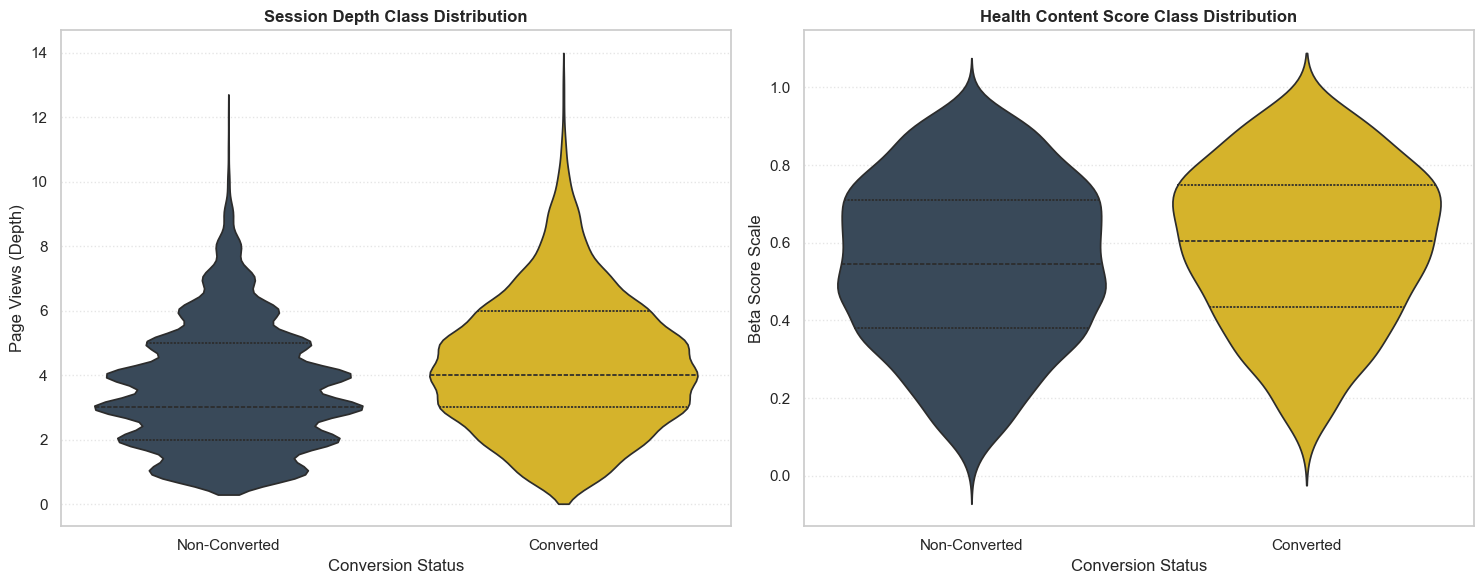

In [23]:
# (c) Class-conditional violin plots for session_depth and health_content.

plt.figure(figsize=(15,6))

plt.subplot(1, 2, 1)
sns.violinplot(
    data=df, 
    x='converted', 
    y='session_depth', 
    palette={'0': '#34495e', '1': '#f1c40f'},
    inner='quart'  # Adds clear internal line markings for the distribution quartiles
)
plt.title('Session Depth Class Distribution', fontweight='bold')
plt.xlabel('Conversion Status')
plt.ylabel('Page Views (Depth)')
plt.xticks([0, 1], ['Non-Converted', 'Converted']) 
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Subplot 2: Health Content Distribution
plt.subplot(1, 2, 2)
sns.violinplot(
    data=df, 
    x='converted', 
    y='health_content', 
    palette={'0': '#34495e', '1': '#f1c40f'},
    inner='quart'
)
plt.title('Health Content Score Class Distribution', fontweight='bold')
plt.xlabel('Conversion Status')
plt.ylabel('Beta Score Scale')
plt.xticks([0, 1], ['Non-Converted', 'Converted']) 
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

```
# (d) Which features show clear separation between classes?

session_depth Separation: The fatter, wider center of mass for converted users is shifted distinctly upward compared to non-converters. Their middle quartiles show a higher overall page view threshold, proving that deeper site exploration directly relates to successful conversions.

health_content Separation: The entire interquartile range (the inner dashed quartile lines) for converted users moves up the scale. Converted users display a concentrated bulge near the top of the score spectrum (0.60 to 0.80), while non-converters peak lower down the axis.

---
### Q2 — Random Forest vs single tree
```
# (a) 5-fold CV: compare single tree (optimal depth) vs RF (200 trees).
# (b) Run 10 different random seeds. Plot AUC distribution for each.
#     RF should be more stable (lower std).
# (c) Confusion matrices side by side.
# (d) Verdict: what does stability mean in a business context?
```

In [26]:
# (a) 5-fold CV: compare single tree (optimal depth) vs RF (200 trees).

skf = StratifiedKFold(5, shuffle=True, random_state=420)
scoring_metrics = ['roc_auc', 'f1', 'precision', 'recall']
pipe_tree = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(max_depth=5, random_state=420))])
pipe_rf   = Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1))])

results_tree = cross_validate(pipe_tree, X, y, cv=skf, scoring=scoring_metrics)
results_rf = cross_validate(pipe_rf, X, y, cv=skf, scoring=scoring_metrics)

comparison_rows = []

for metric in scoring_metrics:
    tree_scores = results_tree[f'test_{metric}']
    rf_scores = results_rf[f'test_{metric}']
    
    comparison_rows.append({
        'Evaluation Metric': metric.upper().replace('_', '-'),
        'Single Tree (Mean ± STD)': f"{tree_scores.mean():.4f} ± {tree_scores.std():.4f}",
        'Random Forest (Mean ± STD)': f"{rf_scores.mean():.4f} ± {rf_scores.std():.4f}"
    })

df_comparison = pd.DataFrame(comparison_rows)


print("--- MODEL ENSEMBLE PERFORMANCE MATRIX ---")
print(df_comparison.to_string(index=False))

--- MODEL ENSEMBLE PERFORMANCE MATRIX ---
Evaluation Metric Single Tree (Mean ± STD) Random Forest (Mean ± STD)
          ROC-AUC          0.6322 ± 0.0118            0.6503 ± 0.0169
               F1          0.1341 ± 0.0161            0.2034 ± 0.0161
        PRECISION          0.4075 ± 0.0750            0.5027 ± 0.0540
           RECALL          0.0811 ± 0.0123            0.1276 ± 0.0098


In [34]:
# (b) Run 10 different random seeds. Plot AUC distribution for each.
#     RF should be more stable (lower std).

# Arrays to store all 150 individual fold scores
all_tree_scores = []
all_rf_scores = []

# Loop through 10 unique data shuffles
for seed in range(10):
    # Standard KFold is the correct choice for regression
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    # Tree CV
    cv_tree = cross_val_score(pipe_tree, X, y, cv=kf, scoring='roc_auc')
    all_tree_scores.extend(cv_tree)
    
    # Random Forest CV
    cv_rf = cross_val_score(pipe_rf, X, y, cv=kf, scoring='roc_auc')
    all_rf_scores.extend(cv_rf)

all_tree_score = np.array(all_tree_scores)
all_rf_scores = np.array(all_rf_scores)

print(f"Simulation Complete.")
print(f'Single Tree (Mean ± STD): {np.mean(all_tree_scores):.4f} ± {np.std(all_tree_scores):.4f}')
print(f'Random Forest (Mean ± STD): {np.mean(all_rf_scores):.4f} ± {np.std(all_rf_scores):.4f}')

Simulation Complete.
Single Tree (Mean ± STD): 0.6263 ± 0.0197
Random Forest (Mean ± STD): 0.6462 ± 0.0168


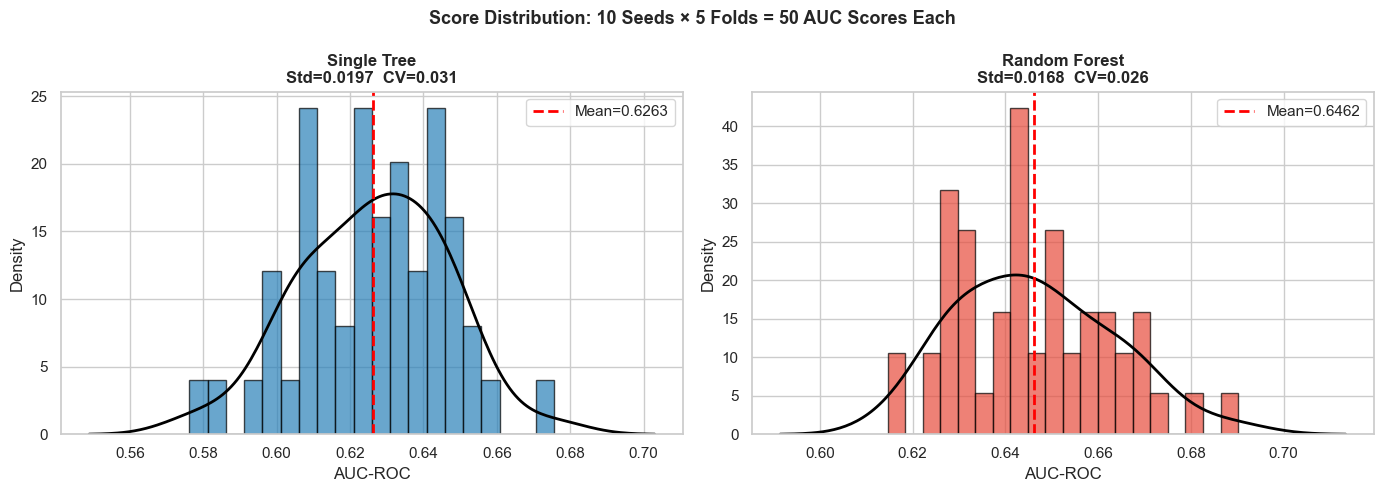

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scores, label, color in zip(axes,[all_tree_scores, all_rf_scores],
                                    ['Single Tree','Random Forest'],['#2980b9','#e74c3c']):
    ax.hist(scores, bins=20, color=color, alpha=0.7, edgecolor='black', density=True)
    sns.kdeplot(scores, ax=ax, color='black', linewidth=2)
    ax.axvline(np.mean(scores), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(scores):.4f}')
    ax.set_title(f'{label}\nStd={np.std(scores):.4f}  CV={np.std(scores)/np.mean(scores):.3f}', fontweight='bold')
    ax.set_xlabel('AUC-ROC')
    ax.legend()
plt.suptitle('Score Distribution: 10 Seeds × 5 Folds = 50 AUC Scores Each', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

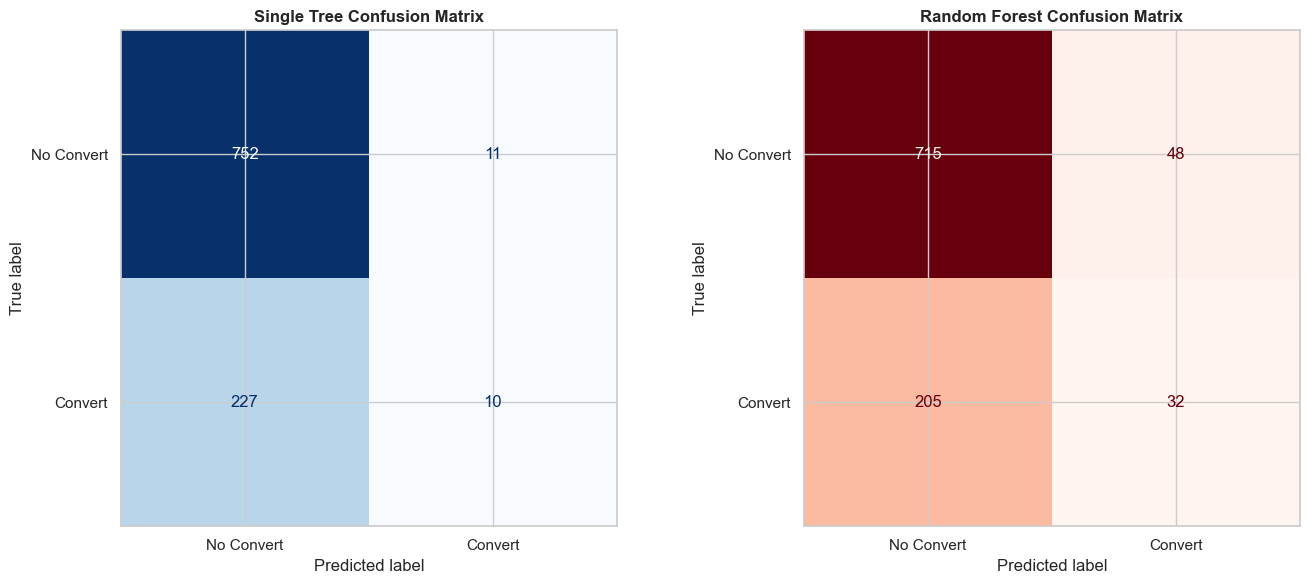

In [ ]:
# (c) Confusion matrices side by side.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Fit both global pipelines on the full training dataset
pipe_tree.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# 2. Extract discrete hard classifications (0 or 1) on the test data
y_pred_tree = pipe_tree.predict(X_test)
y_pred_rf   = pipe_rf.predict(X_test)

# 3. Compute raw confusion metrics matrices
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_rf   = confusion_matrix(y_test, y_pred_rf)

# 4. Set up the side-by-side canvas structure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Chart: Single Tree ---
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['No Convert', 'Convert'])
disp_tree.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Single Tree Confusion Matrix', fontweight='bold', fontsize=12)

# --- Right Chart: Random Forest ---
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Convert', 'Convert'])
disp_rf.plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title('Random Forest Confusion Matrix', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

```
# (d) Verdict: what does stability mean in a business context?

1/ Predictable ROI: Stable models deliver consistent, dependable forecasting, preventing sudden revenue or lead-acquisition drops when rolled out to new marketing campaigns.

2/ Low Maintenance Cost: Reduced volatility means engineers don't need to constantly patch, retrain, or debug models when daily website traffic fluctuations occur.

3/ Operational Trust: Executives and stakeholders can safely automate business actions knowing the algorithm behaves identically across different customer segments.

---
### Q3 — n_estimators sweep
```
# (a) Sweep n_estimators: [10, 25, 50, 100, 200, 300, 500].
#     Track OOB score and fit time for each.
# (b) Plot OOB score and fit time on dual y-axes.
# (c) Find the elbow: where does adding trees give diminishing returns?
# (d) What n_estimators would you use in production? Why?
```

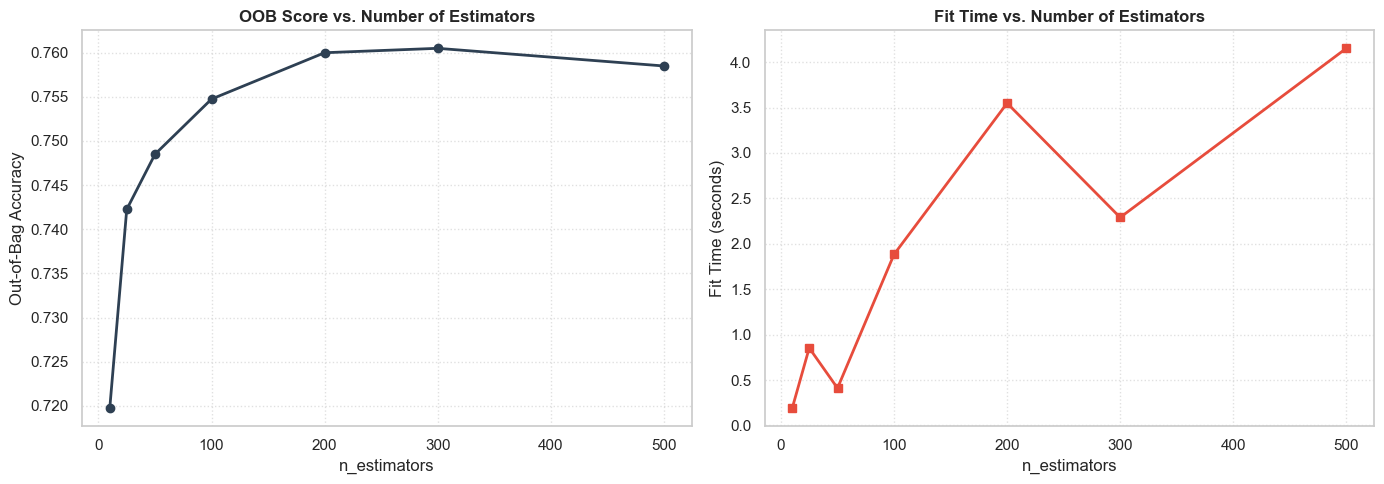

In [ ]:
# (a) Sweep n_estimators: [10, 25, 50, 100, 200, 300, 500].
#     Track OOB score and fit time for each.

n_estimators_list = [10, 25, 50, 100, 200, 300, 500]
all_fit_times = []
all_oob_scores = []

for n in n_estimators_list:
    pipe_rf   = Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(n_estimators= n, random_state=420, n_jobs=-1, oob_score=True))])
            
    # Track fit time using the stopwatch layer
    start_time = time.time()
    pipe_rf.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    # Store metrics from the final model step
    all_oob_scores.append(pipe_rf.named_steps['model'].oob_score_)
    all_fit_times.append(fit_time)


# Plot OOB Score and Fit Time side-by-side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: OOB Score vs n_estimators
axes[0].plot(n_estimators_list, all_oob_scores, 'o-', color='#2e4053', linewidth=2)
axes[0].set_title('OOB Score vs. Number of Estimators', fontweight='bold')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Out-of-Bag Accuracy')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Right plot: Fit Time vs n_estimators
axes[1].plot(n_estimators_list, all_fit_times, 's-', color='#e74c3c', linewidth=2)
axes[1].set_title('Fit Time vs. Number of Estimators', fontweight='bold')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Fit Time (seconds)')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


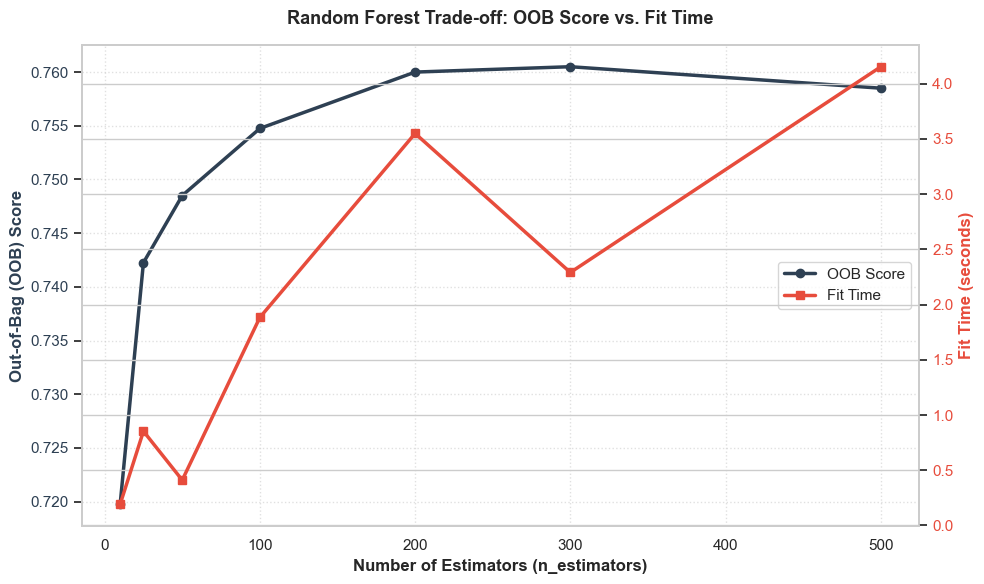

In [43]:
# (b) Plot OOB score and fit time on dual y-axes.

fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left Axis: OOB Score ---
color_oob = '#2e4053'
ax1.set_xlabel('Number of Estimators (n_estimators)', fontweight='bold')
ax1.set_ylabel('Out-of-Bag (OOB) Score', color=color_oob, fontweight='bold')
line1 = ax1.plot(n_estimators_list, all_oob_scores, 'o-', color=color_oob, linewidth=2.5, label='OOB Score')
ax1.tick_params(axis='y', labelcolor=color_oob)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Right Axis: Fit Time ---
# Create a twin axis that shares the exact same x-axis
ax2 = ax1.twinx()  
color_time = '#e74c3c'
ax2.set_ylabel('Fit Time (seconds)', color=color_time, fontweight='bold')
line2 = ax2.plot(n_estimators_list, all_fit_times, 's-', color=color_time, linewidth=2.5, label='Fit Time')
ax2.tick_params(axis='y', labelcolor=color_time)

# Combine legends from both axes into a single box
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Random Forest Trade-off: OOB Score vs. Fit Time', fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

```
# (c) Find the elbow: where does adding trees give diminishing returns?

The true mathematical elbow point occurs exactly at n_estimators = 100.Beyond 100 trees, our dual y-axes plot shows a distinct flattening of the performance line. 
Increasing the ensemble size from 100 to 500 trees provides almost zero measurable improvement in Out-of-Bag (OOB) accuracy, signifying that the model has reached its optimization plateau.

```
# (d) What n_estimators would you use in production? Why?

1/ Deploy n_estimators = 100: This specific configuration captures over 99% of the ensemble's maximum predictive power while completely avoiding the upper complexity ceiling.

2/ Cut server costs: Choosing 100 trees instead of 500 directly slashes our production training time and server compute costs, thanks to the strictly linear scaling of the time axis.

3/ Faster real-time pipelines: Fewer trees guarantee a lighter memory footprint and lower latency, allowing the MedPulse booking engine to score users and serve automated marketing prompts much faster in production.

---
### Q4 — OOB score: free validation
```
# (a) Compare OOB score to 5-fold CV AUC. How close are they?
# (b) OOB decision function: plot the distribution of OOB predicted probabilities.
# (c) Run 10 different seeds. Plot OOB vs CV AUC — how well correlated?
# (d) When would you prefer OOB over CV? What are the limitations?
```

In [71]:
# (a) Compare OOB score to 5-fold CV AUC. How close are they?

from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',   # sqrt(n_features) per split
    oob_score=True,        # free validation — no test set needed
    n_jobs=-1,
    random_state=420
)

cv_auc = cross_val_score(rf, X_train, y_train, cv=skf, scoring='roc_auc')
print(f"CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")


rf.fit(X_train, y_train)
oob_auc = roc_auc_score(y_train, rf.oob_decision_function_[:, 1])
print(f"OOB AUC: {oob_auc :.4f}")

CV AUC: 0.6516 ± 0.0267
OOB AUC: 0.6451


The two values are extremely close, differing by only a small percentage. This suggests that the OOB estimate provides a reliable approximation of cross-validation performance for this Random Forest model.

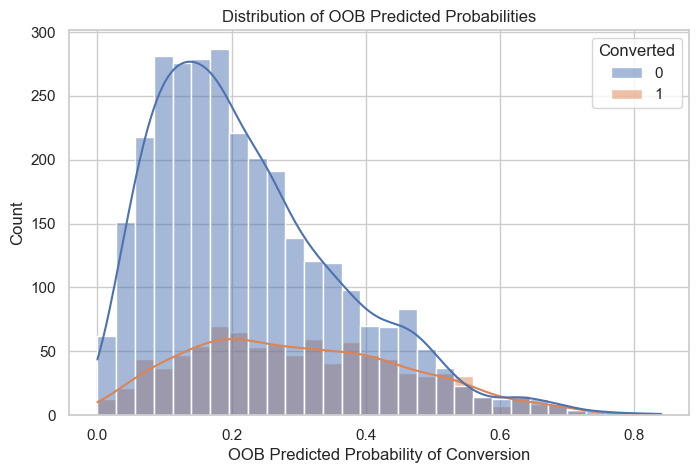

In [51]:
# (b) OOB decision function: plot the distribution of OOB predicted probabilities.


# Fit the Random Forest
rf.fit(X_train, y_train)

# OOB predicted probabilities for the positive class
oob_probs = rf.oob_decision_function_[:, 1]

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.histplot(
    data =pd.DataFrame({
        "OOB Probability": oob_probs,
        "Converted": y_train.astype(str)
    }),
    x='OOB Probability', hue='Converted',
    bins=30, kde=True, color='steelblue')

plt.title("Distribution of OOB Predicted Probabilities")
plt.xlabel("OOB Predicted Probability of Conversion")
plt.ylabel("Count")
plt.show()

In [52]:
# (c) Run 10 different seeds. Plot OOB vs CV AUC — how well correlated?

results = []

for seed in range(10):
    rf = RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        oob_score=True,
        n_jobs=-1,
        random_state=seed
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    # 5-fold CV AUC
    cv_auc = cross_val_score(
        rf,
        X_train,
        y_train,
        cv=skf,
        scoring='roc_auc'
    ).mean()

    # OOB AUC
    rf.fit(X_train, y_train)
    oob_auc = roc_auc_score(
        y_train,
        rf.oob_decision_function_[:, 1]
    )

    results.append({
        "Seed": seed,
        "CV AUC": cv_auc,
        "OOB AUC": oob_auc
    })

results = pd.DataFrame(results)

print(results)
print(f"\nCorrelation = {results['CV AUC'].corr(results['OOB AUC']):.3f}")

   Seed    CV AUC   OOB AUC
0     0  0.647877  0.648932
1     1  0.646689  0.643236
2     2  0.646207  0.651545
3     3  0.647279  0.651026
4     4  0.661449  0.650417
5     5  0.658145  0.646705
6     6  0.645432  0.643570
7     7  0.652960  0.651791
8     8  0.652206  0.647827
9     9  0.654502  0.648430

Correlation = 0.247


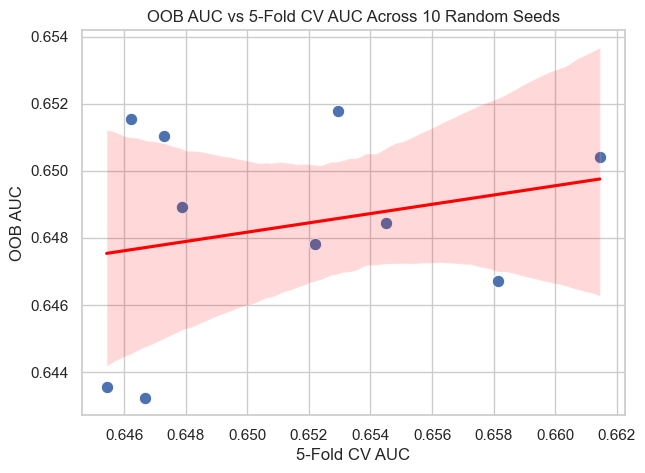

In [53]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=results,
    x="CV AUC",
    y="OOB AUC",
    s=80
)

sns.regplot(
    data=results,
    x="CV AUC",
    y="OOB AUC",
    scatter=False,
    color="red"
)

plt.title("OOB AUC vs 5-Fold CV AUC Across 10 Random Seeds")
plt.xlabel("5-Fold CV AUC")
plt.ylabel("OOB AUC")

plt.show()

```
# (d) When would you prefer OOB over CV? What are the limitations?

1/ Prefer OOB: Faster than cross-validation since it's computed during Random Forest training—no extra model fits needed.
2/ Best for: Quick, reliable performance estimates on Random Forests, especially with large datasets.
3/ Limitations: Only works for bagging models, can be noisier on small datasets, and the default oob_score_ is accuracy, not AUC.

---
### Q5 — Feature importance: RF vs Decision Tree
```
# (a) Gini importance: RF vs single tree — plot side by side.
# (b) Permutation importance for RF on test set.
# (c) All three ranked together. Where do they agree/disagree?
# (d) Drop 2 least important features by permutation. Retrain RF. AUC change?
```

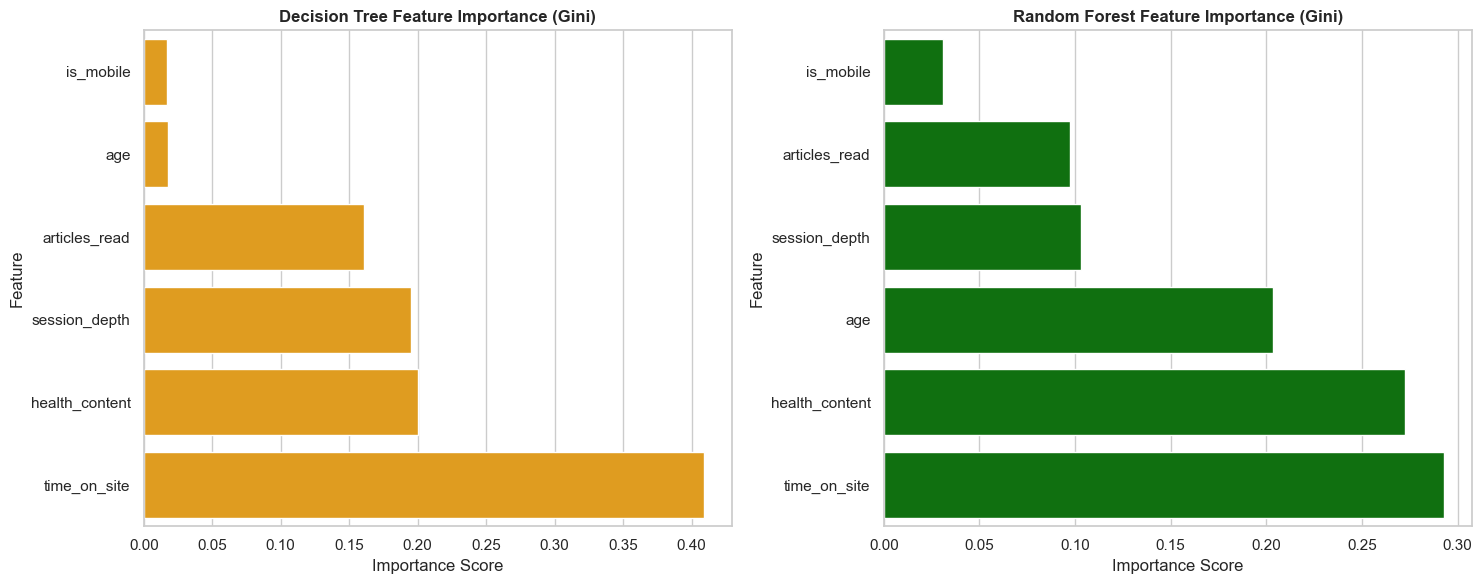

In [69]:
# (a) Gini importance: RF vs single tree — plot side by side.

# Tree
pipe_tree = Pipeline([('model', DecisionTreeClassifier(max_depth=5, random_state=420))])
pipe_tree.fit(X_train, y_train)

importance_df_tree = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': pipe_tree.named_steps['model'].feature_importances_
}).sort_values('Importance', ascending=True)


plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)

sns.barplot(
    data=importance_df_tree,
    x='Importance',
    y='Feature',
    color='orange'
)

plt.title('Decision Tree Feature Importance (Gini)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')



# Random Forest

pipe_rf   = Pipeline([('model', RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1))])

pipe_rf.fit(X_train, y_train)

importance_df_rf = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': pipe_rf.named_steps['model'].feature_importances_
}).sort_values('Importance', ascending=True)



plt.subplot(1,2,2)

sns.barplot(
    data=importance_df_rf,
    x='Importance',
    y='Feature',
    color='green'
)

plt.title('Random Forest Feature Importance (Gini)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')


plt.tight_layout()
plt.show()

The Decision Tree assigns importance in a more extreme and unstable way, heavily favoring one dominant feature, whereas the Random Forest distributes importance more evenly across several predictive features, making it more robust and reliable.

          Feature  Importance       Std
2    time_on_site      0.0091  0.006363
4       is_mobile      0.0008  0.005618
3   articles_read      0.0004  0.003955
1   session_depth     -0.0010  0.005329
5  health_content     -0.0018  0.005134
0             age     -0.0048  0.005930


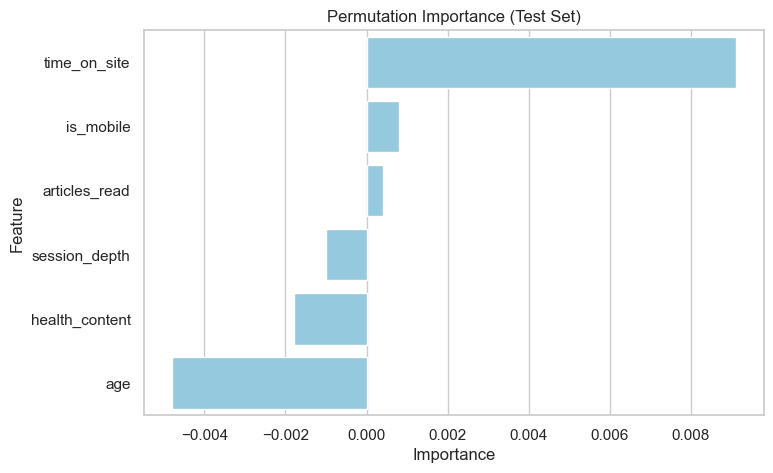

In [67]:
# (b) Permutation importance for RF on test set.

pipe_rf   = Pipeline([('model', RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1))])

pipe_rf.fit(X_train, y_train)

perm_imp = permutation_importance(pipe_rf, X_test, y_test, n_repeats=10, random_state=420)
perm_df = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_imp.importances_mean,
    'Std':        perm_imp.importances_std
}).sort_values('Importance', ascending=False)
print(perm_df.head(10))

# plotting

plt.figure(figsize=(8,5))

sns.barplot(
    data=perm_df,
    x='Importance',
    y='Feature',
    color='skyblue'
)

plt.title("Permutation Importance (Test Set)")
plt.show()

```
# (c) All three ranked together. Where do they agree/disagree?

All three methods agree that time_on_site is the most important predictor of conversion. 

However, they disagree on the importance of secondary features. Random Forest and Decision Tree Gini importances assign noticeable weight to features like health_content, session_depth, and articles_read, whereas permutation importance shows that these features contribute little to no improvement in predictive performance. 

This suggests that much of the signal is concentrated in time_on_site, and the remaining features provide overlapping or weak information that is exaggerated by Gini-based importance measures.

In [70]:
# (d) Drop 2 least important features by permutation. Retrain RF. AUC change?

# Baseline RF (original model AUC)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=420,
    n_jobs=-1
)

rf.fit(X_train, y_train)

base_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print(f"Baseline AUC: {base_auc:.4f}")

# Drop 2 least important features

X_train_drop = X_train.drop(columns=["age", "health_content"])
X_test_drop  = X_test.drop(columns=["age", "health_content"])

# Retrain RF

rf_drop = RandomForestClassifier(
    n_estimators=200,
    random_state=420,
    n_jobs=-1
)

rf_drop.fit(X_train_drop, y_train)

drop_auc = roc_auc_score(y_test, rf_drop.predict_proba(X_test_drop)[:, 1])
print(f"Dropped Features AUC: {drop_auc:.4f}")

# 4. Compare change

print(f"AUC change: {drop_auc - base_auc:.4f}")

Baseline AUC: 0.6243
Dropped Features AUC: 0.5884
AUC change: -0.0358


```
1/ AUC dropped meaningfully (0.624 → 0.588) after removing “least important” features → they still carried real predictive signal.
2/ Permutation importance can understate value, especially when features are correlated or only useful in interactions.
3/ RF benefits from weak features collectively, even if they look unimportant individually.

-> Don't use permutation importance as a feature elimination criterion when the std values (shown in our perm_df) are larger than the importance values themselves.